# Loan Approval Prediction - Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to understand the loan prediction dataset through exploratory data analysis (EDA). This includes:

- Understanding the dataset
- Checking missing values
- Performing statistical analysis
- Visualizing the data
- Identifying patterns between features
- Drawing insights before preprocessing and model building

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("fivethirtyeight")
pd.set_option("display.max_columns", None)

# Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv("../Dataset/loan_prediction.csv")

# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Display last 5 rows
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


# Understanding the Dataset

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 614
Columns : 13


In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [12]:
df.describe(include="object").T

,count,unique,top,freq
Loan_ID,614,614,LP001002,1
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


# Missing Value Analysis

In [13]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
print("Duplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [23]:
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# sns.displot(df['ApplicantIncome'],color='r')
# plt.subplot(1,2,2)
# sns.displot(df['Credit_History'])
# plt.show()

# Univariate Analysis

Univariate analysis examines one feature at a time to understand its distribution, frequency, and characteristics.


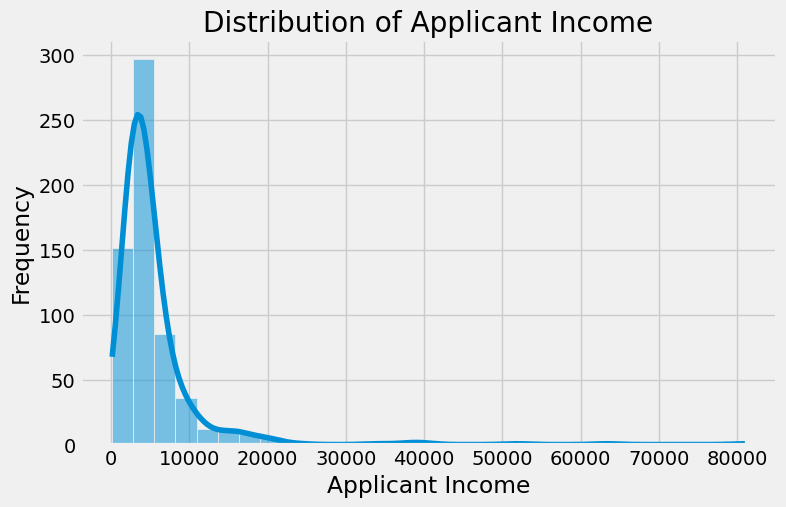

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    kde=True,
    bins=30
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

- Applicant income is positively skewed.
- Most applicants have lower income, while a few have very high income.

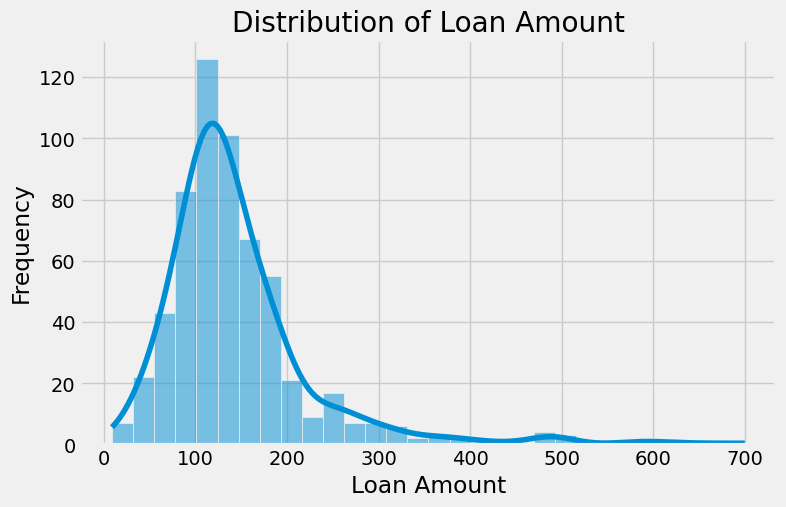

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LoanAmount'],
    kde=True,
    bins=30
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

- Loan amount follows a right-skewed distribution.
- Most loan amounts are concentrated at lower values.

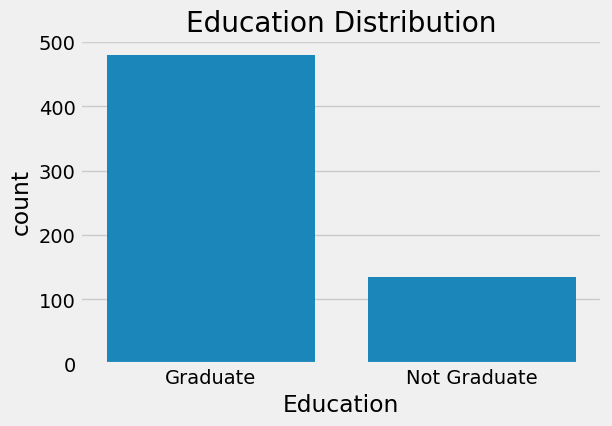

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Education',
    data=df
)

plt.title("Education Distribution")

plt.show()

- Graduate applicants are more than non-graduate applicants.

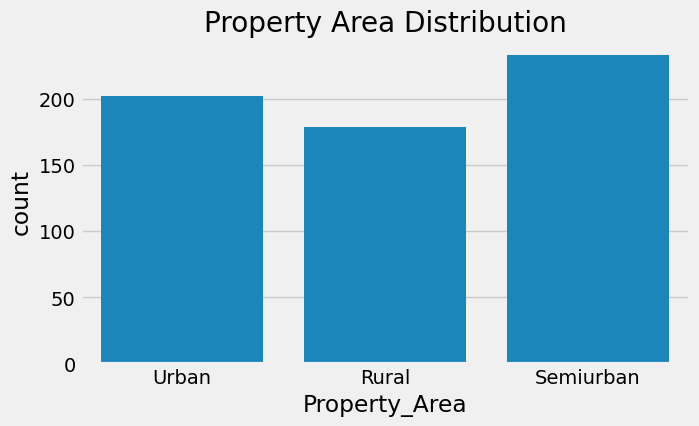

In [54]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='Property_Area',
    data=df
)

plt.title("Property Area Distribution")

plt.show()

- Urban applicants are the highest followed by Semiurban and Rural.

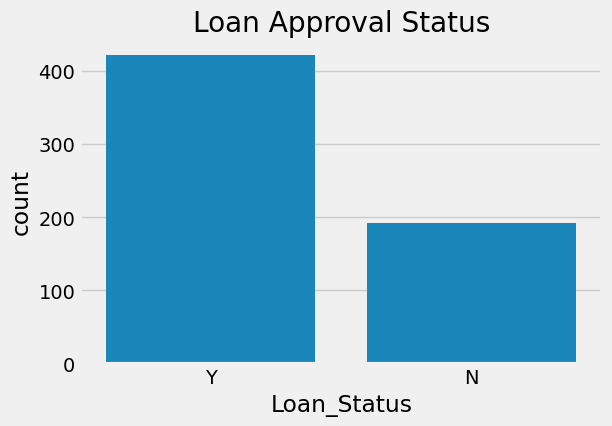

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Loan_Status',
    data=df
)

plt.title("Loan Approval Status")

plt.show()

# Bivariate Analysis

Bivariate analysis helps understand the relationship between two variables and how different features influence loan approval.

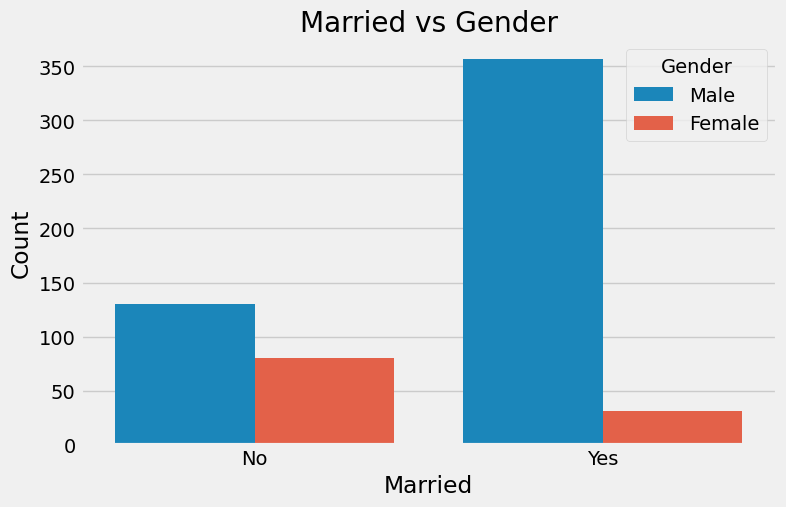

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Married',
    hue='Gender',
    data=df
)

plt.title("Married vs Gender")
plt.xlabel("Married")
plt.ylabel("Count")

plt.show()

- Most married applicants are male.
- Female applicants are fewer in both married and unmarried categories.

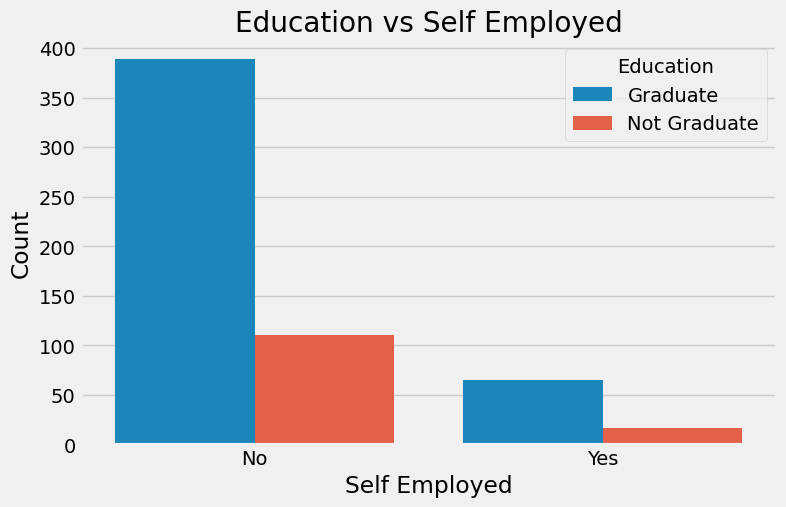

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Self_Employed',
    hue='Education',
    data=df
)

plt.title("Education vs Self Employed")
plt.xlabel("Self Employed")
plt.ylabel("Count")

plt.show()

- Graduate applicants are more common than non-graduates.
- Most applicants are not self-employed regardless of education level.

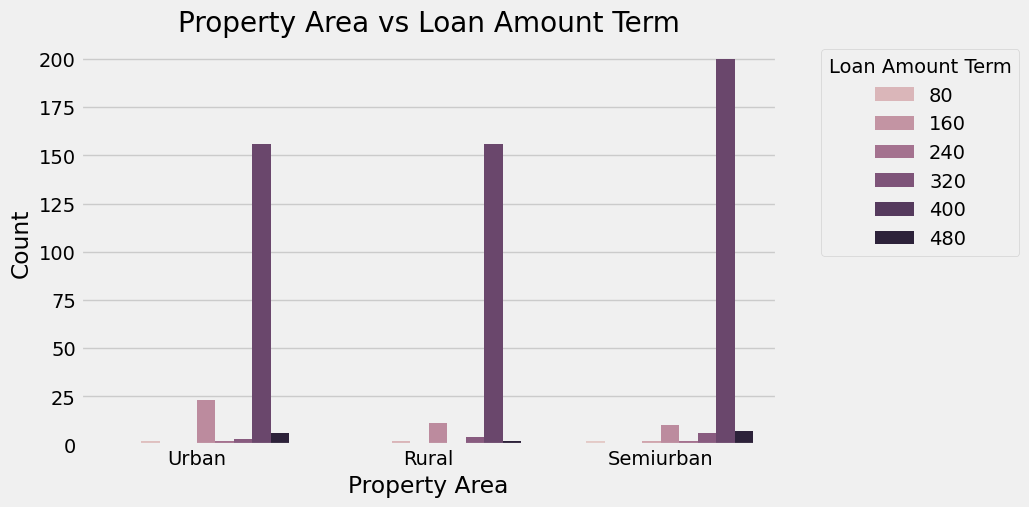

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Property_Area',
    hue='Loan_Amount_Term',
    data=df
)

plt.title("Property Area vs Loan Amount Term")
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.legend(title="Loan Amount Term", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- Urban areas have the highest number of loan applications.
- The 360-month loan term is the most common across all property areas.

### Multivariate Analysis


<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

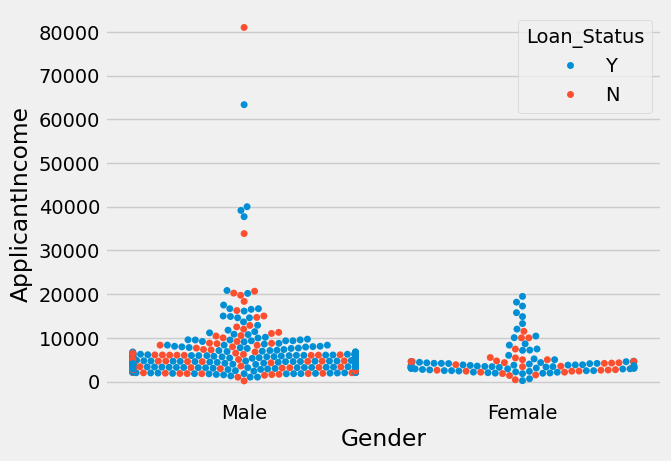

In [50]:
sns.swarmplot(
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    data=df
)